In [1]:
import numpy as np
import matplotlib.pyplot as plt
import keras

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

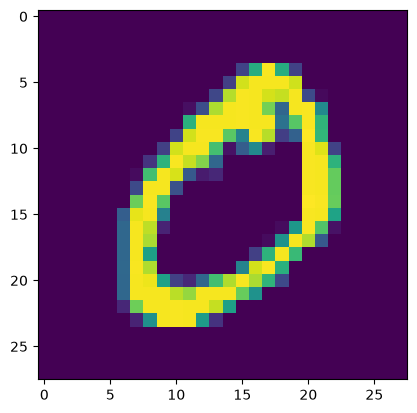

In [3]:
plt.imshow(x_train[1])

In [4]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [5]:
x_train = x_train.reshape(-1, 28*28) / 255.0
x_test = x_test.reshape(-1, 28*28) / 255.0
print(x_train.shape)
print(x_test.shape)

(60000, 784)
(10000, 784)


In [6]:
w1 = np.random.randn(28*28, 128) * 0.01
b1 = np.zeros((1, 128))
w2 = np.random.randn(128, 10) * 0.01
b2 = np.zeros((1, 10))

In [7]:
x = x_train[3:4]
label = y_train[3]
print(x.shape)
print(label)

(1, 784)
1


In [11]:
y = np.zeros((1, 10))
y[0, y_train[3]] = 1
print(f"One-hot encoded y: {y}")

One-hot encoded y: [[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [12]:
for epoch in range(10000):
    # Forward pass
    z1 = np.dot(x, w1) + b1
    a1 = np.maximum(0, z1)  # ReLU activation
    z2 = np.dot(a1, w2) + b2
    exp = np.exp(z2)
    softmax = exp / np.sum(exp, axis=1, keepdims=True)


    # Compute loss (binary cross-entropy)
    loss = -np.log(softmax[0, label])
    
    # Backward pass
    dz2 = softmax - y
    
    dw2 = np.dot(a1.T, dz2)
    db2 = np.sum(dz2, axis=0, keepdims=True)

    da1 = np.dot(dz2, w2.T)
    dz1 = da1 * (z1 > 0)  # Derivative of ReLU

    dw1 = np.dot(x.T, dz1)
    db1 = np.sum(dz1, axis=0, keepdims=True)

    #gradient descent update
    learning_rate = 0.01
    w1 -= learning_rate * dw1
    b1 -= learning_rate * db1

    w2 -= learning_rate * dw2
    b2 -= learning_rate * db2

    if epoch % 100 == 0:
        predicted_class = np.argmax(softmax)
        confidence = softmax[0, predicted_class]
        print(f"Epoch {epoch}: Loss = {loss:.4f}, Predicted class = {predicted_class}, Confidence = {confidence:.4f}")  

Epoch 0: Loss = 11.9103, Predicted class = 0, Confidence = 0.9999
Epoch 100: Loss = 0.0110, Predicted class = 1, Confidence = 0.9891
Epoch 200: Loss = 0.0046, Predicted class = 1, Confidence = 0.9954
Epoch 300: Loss = 0.0028, Predicted class = 1, Confidence = 0.9972
Epoch 400: Loss = 0.0020, Predicted class = 1, Confidence = 0.9980
Epoch 500: Loss = 0.0015, Predicted class = 1, Confidence = 0.9985
Epoch 600: Loss = 0.0012, Predicted class = 1, Confidence = 0.9988
Epoch 700: Loss = 0.0010, Predicted class = 1, Confidence = 0.9990
Epoch 800: Loss = 0.0009, Predicted class = 1, Confidence = 0.9991
Epoch 900: Loss = 0.0008, Predicted class = 1, Confidence = 0.9992
Epoch 1000: Loss = 0.0007, Predicted class = 1, Confidence = 0.9993
Epoch 1100: Loss = 0.0006, Predicted class = 1, Confidence = 0.9994
Epoch 1200: Loss = 0.0006, Predicted class = 1, Confidence = 0.9994
Epoch 1300: Loss = 0.0005, Predicted class = 1, Confidence = 0.9995
Epoch 1400: Loss = 0.0005, Predicted class = 1, Confidence 

In [13]:
# Forward pass
z1 = np.dot(x, w1) + b1
a1 = np.maximum(0, z1)  # ReLU activation
z2 = np.dot(a1, w2) + b2
exp = np.exp(z2)
softmax = exp / np.sum(exp, axis=1, keepdims=True)

prediction = np.argmax(softmax)
confidence = softmax[0, prediction]

print(f"Final Prediction: {prediction}, Confidence: {confidence:.4f}")

Final Prediction: 1, Confidence: 0.9999
